In [ ]:
!pip install numpy pandas matplotlib

  Using cached pandas-2.3.3-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.3 kB)
  Using cached pillow-12.1.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.1-py3-none-any.whl.metadata (5.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/1

In [14]:
#!/usr/bin/env python3

import csv, pathlib, sys

SRC_DIR = pathlib.Path('data/config_data')          # root that contains trial_*/
XYZ_DIR = 'xyz'                                # sub-folder that will hold .xyz files
SPECIES = 'A'                                  # same species for every particle

def csv_to_xyz(csv_path, xyz_path):
    """Read x,y,vx,vy csv and write minimal xyz file."""
    with csv_path.open(newline='') as fc, xyz_path.open('w') as fx:
        rows = list(csv.DictReader(fc))          # first line is header
        fx.write(f'{len(rows)}\n')
        fx.write('Properties=id:I:1:pos:R:2:velo:R:2:species:S:1\n')
        for i, r in enumerate(rows):
            x, y   = float(r['x']), float(r['y'])
            vx, vy = float(r['vx']), float(r['vy'])
            fx.write(f'{i} {x} {y} {vx} {vy} {SPECIES}\n')

def main():
    if not SRC_DIR.is_dir():
        sys.exit(f'Folder {SRC_DIR} not found – run this script from the project root.')

    trials = [d for d in SRC_DIR.iterdir() if d.is_dir() and d.name.startswith('trial_')]
    if not trials:
        sys.exit('No trial_*/ directories inside config_data/')

    for trial in trials:
        csv_folder = trial
        xyz_folder = trial / XYZ_DIR
        xyz_folder.mkdir(exist_ok=True)

        csv_files = sorted(csv_folder.glob('config_*.csv'))
        if not csv_files:
            print(f'No cLsv files in {trial}, skipping')
            continue

        for csv_file in csv_files:
            num = csv_file.stem.split('_')[1]          # config_123.csv → 123
            xyz_file = xyz_folder / f'config_{num}.xyz'
            csv_to_xyz(csv_file, xyz_file)

        print(f'converted {len(csv_files)} snapshots → {xyz_folder}')

if __name__ == '__main__':
    main()

converted 127 snapshots → data/config_data/trial_0/xyz


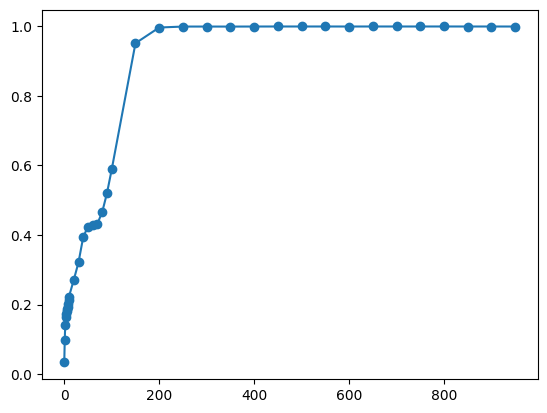

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
data=pd.read_csv("/home/ogbeeper/Projects/Vicsek_vision_V3/Angle_45/Noise_0.05/data/order_data/order_parameter_0_.csv")
plt.plot(data["t"],data["va"],marker="o")
plt.show()